# Shortest Path in Binary Matrix
Given an n x n binary matrix grid, return the length of the shortest clear path in the matrix. If there is no clear path, return -1.

A clear path in a binary matrix is a path from the top-left cell (i.e., (0, 0)) to the bottom-right cell (i.e., (n - 1, n - 1)) such that:

All the visited cells of the path are 0.
All the adjacent cells of the path are 8-directionally connected (i.e., they are different and they share an edge or a corner).
The length of a clear path is the number of visited cells of this path.

[Leetcode Link](https://leetcode.com/problems/shortest-path-in-binary-matrix/description/)


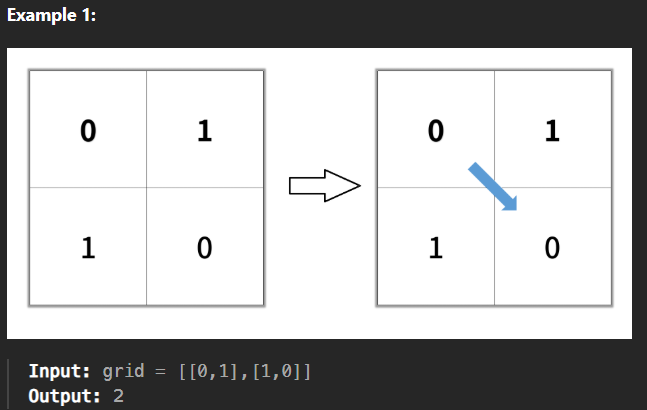

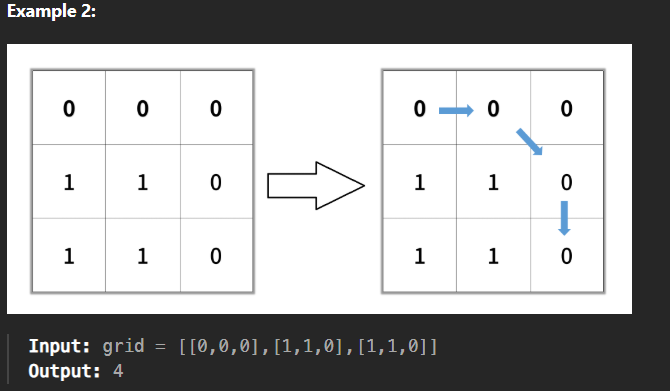

Example 3:

Input: grid = [[1,0,0],[1,1,0],[1,1,0]]
Output: -1

### Constraints
* n == grid.length
* n == grid[i].length
* 1 <= n <= 100
* grid[i][j] is 0 or 1

## Breath-First Search Approach

We cannot use depth-first search to find the optimal path because each time it starts a new path, it marks visited cells. Depth first search has to complete a path before starting the next path. If a prior path had cells that overlapped with the optimal path, then the DFS algorithm will stop exploring the optimal path when it finds that the cells are already visited.

In contrast, the BFS algorithm will explore one step in all the possible paths before moving onto the next step in the paths. This ensures that we visit the entire optimal path. This path will be the first path we find that terminates at the bottom-right cell.

### Analysis
* Time complexity: $O(N^2)$
* Space complexity: $O(N^2)$
    * `seen` set could end up storing all the nodes

In [ ]:
from collections import deque

def shortestPathBinaryMatrix(grid: List[List[int]]) -> int:
    n = len(grid)
    if grid[0][0] == 1 or grid[n-1][n-1] == 1:
        return -1
    if n == 1:
        return 1
    end = (n - 1, n - 1)
    neighbors = {(i,j) for i in range(-1,2) for j in range(-1,2)}
    neighbors.discard((0,0))
    shortest_path = 1
    seen = {(0,0)}
    cell_queue = deque([(0,0)])
    while cell_queue:
        shortest_path += 1
        layer = len(cell_queue)
        for i in range(layer):
            current = cell_queue.popleft()
            for neighbor in neighbors:
                new_neighbor = (neighbor[0] + current[0], neighbor[1] + current[1])
                if new_neighbor == end:
                    return shortest_path
                if new_neighbor[0] < 0 or new_neighbor[0] >= n or new_neighbor[1] < 0 or new_neighbor[1] >= n:
                    continue
                elif grid[new_neighbor[0]][new_neighbor[1]] != 0:
                    continue
                elif new_neighbor in seen:
                    continue
                cell_queue.append(new_neighbor)
                seen.add(new_neighbor)
    return -1